In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import polars.selectors as cs
import pandas as pd
import plotly.express as px

import ipaddress
import datetime as dt

In [2]:
pl.Config.set_engine_affinity("streaming")

polars.config.Config

In [3]:
df_path = '/mnt/samsung/Datasets/csv_data/network_intrudtion/*.csv'

In [4]:
df = pl.scan_csv(
    df_path,
    include_file_paths='path',
    # infer_schema=False,
    # ignore_errors=True,
)

In [5]:
df

Schema([(' Destination Port', Int64),
        (' Flow Duration', Int64),
        (' Total Fwd Packets', Int64),
        (' Total Backward Packets', Int64),
        ('Total Length of Fwd Packets', Int64),
        (' Total Length of Bwd Packets', Int64),
        (' Fwd Packet Length Max', Int64),
        (' Fwd Packet Length Min', Int64),
        (' Fwd Packet Length Mean', Float64),
        (' Fwd Packet Length Std', Float64),
        ('Bwd Packet Length Max', Int64),
        (' Bwd Packet Length Min', Int64),
        (' Bwd Packet Length Mean', Float64),
        (' Bwd Packet Length Std', Float64),
        ('Flow Bytes/s', String),
        (' Flow Packets/s', String),
        (' Flow IAT Mean', Float64),
        (' Flow IAT Std', Float64),
        (' Flow IAT Max', Int64),
        (' Flow IAT Min', Int64),
        ('Fwd IAT Total', Int64),
        (' Fwd IAT Mean', Float64),
        (' Fwd IAT Std', Float64),
        (' Fwd IAT Max', Int64),
        (' Fwd IAT Min', Int64),
        ('B

In [6]:
df = df.rename(lambda column: column.strip().lower().replace(' ', '_'))

In [7]:
df.select(
    pl.all().null_count()
)

In [8]:
df.select(
    pl.all().n_unique()
).collect(engine='streaming')

destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_max,bwd_packet_length_min,bwd_packet_length_mean,bwd_packet_length_std,flow_bytes/s,flow_packets/s,flow_iat_mean,flow_iat_std,flow_iat_max,flow_iat_min,fwd_iat_total,fwd_iat_mean,fwd_iat_std,fwd_iat_max,fwd_iat_min,bwd_iat_total,bwd_iat_mean,bwd_iat_std,bwd_iat_max,bwd_iat_min,fwd_psh_flags,bwd_psh_flags,fwd_urg_flags,bwd_urg_flags,fwd_header_length,bwd_header_length,fwd_packets/s,…,fin_flag_count,syn_flag_count,rst_flag_count,psh_flag_count,ack_flag_count,urg_flag_count,cwe_flag_count,ece_flag_count,down/up_ratio,average_packet_size,avg_fwd_segment_size,avg_bwd_segment_size,fwd_header_length_duplicated_0,fwd_avg_bytes/bulk,fwd_avg_packets/bulk,fwd_avg_bulk_rate,bwd_avg_bytes/bulk,bwd_avg_packets/bulk,bwd_avg_bulk_rate,subflow_fwd_packets,subflow_fwd_bytes,subflow_bwd_packets,subflow_bwd_bytes,init_win_bytes_forward,init_win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label,path
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
53805,1050899,1432,1747,17928,64698,5279,384,99716,253909,4838,583,147614,248869,1593909,1240164,1166311,1056642,580289,136316,493098,737737,700313,437316,110631,414928,670824,709042,368285,66074,2,1,2,1,3771,3945,1220423,…,2,2,2,2,2,2,2,2,31,212207,99716,147611,3771,1,1,1,1,1,1,1432,17928,1747,64738,12151,13112,1093,28,326325,202826,299565,175670,222016,197616,149737,223888,15,8


In [9]:
df.sink_parquet(
    pl.PartitionBy(
        base_path='/mnt/samsung/Datasets/parquet_data/network_intrudtion/',
        max_rows_per_file=500_000,
        key=['label', 'path'],

    ),
    mkdir=True,
)

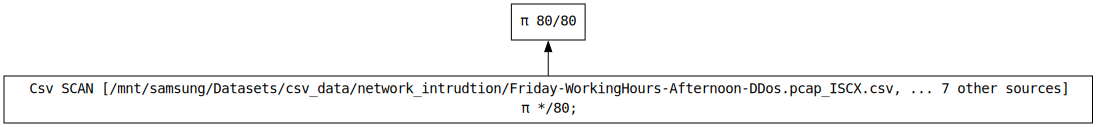

In [10]:
df.show_graph()

In [11]:
df.explain()

'SELECT [col(" Destination Port").alias("destination_port"), col(" Flow Duration").alias("flow_duration"), col(" Total Fwd Packets").alias("total_fwd_packets"), col(" Total Backward Packets").alias("total_backward_packets"), col("Total Length of Fwd Packets").alias("total_length_of_fwd_packets"), col(" Total Length of Bwd Packets").alias("total_length_of_bwd_packets"), col(" Fwd Packet Length Max").alias("fwd_packet_length_max"), col(" Fwd Packet Length Min").alias("fwd_packet_length_min"), col(" Fwd Packet Length Mean").alias("fwd_packet_length_mean"), col(" Fwd Packet Length Std").alias("fwd_packet_length_std"), col("Bwd Packet Length Max").alias("bwd_packet_length_max"), col(" Bwd Packet Length Min").alias("bwd_packet_length_min"), col(" Bwd Packet Length Mean").alias("bwd_packet_length_mean"), col(" Bwd Packet Length Std").alias("bwd_packet_length_std"), col("Flow Bytes/s").alias("flow_bytes/s"), col(" Flow Packets/s").alias("flow_packets/s"), col(" Flow IAT Mean").alias("flow_iat_

In [12]:
df.select(
    pl.col('label').unique()
).collect().get_column('label').to_list()

['DDoS',
 'FTP-Patator',
 'DoS Hulk',
 'Web Attack � Sql Injection',
 'Bot',
 'Web Attack � Brute Force',
 'SSH-Patator',
 'Web Attack � XSS',
 'DoS Slowhttptest',
 'BENIGN',
 'Heartbleed',
 'DoS GoldenEye',
 'PortScan',
 'Infiltration',
 'DoS slowloris']

In [13]:
df.select(
    pl.col('path').unique()
).collect().to_series().to_list()

['/mnt/samsung/Datasets/csv_data/network_intrudtion/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 '/mnt/samsung/Datasets/csv_data/network_intrudtion/Monday-WorkingHours.pcap_ISCX.csv',
 '/mnt/samsung/Datasets/csv_data/network_intrudtion/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
 '/mnt/samsung/Datasets/csv_data/network_intrudtion/Tuesday-WorkingHours.pcap_ISCX.csv',
 '/mnt/samsung/Datasets/csv_data/network_intrudtion/Friday-WorkingHours-Morning.pcap_ISCX.csv',
 '/mnt/samsung/Datasets/csv_data/network_intrudtion/Wednesday-workingHours.pcap_ISCX.csv',
 '/mnt/samsung/Datasets/csv_data/network_intrudtion/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 '/mnt/samsung/Datasets/csv_data/network_intrudtion/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv']

In [14]:
df.collect().estimated_size('mb')

1962.4095621109009

In [15]:
df = df.with_columns(
    pl.col("label").cast(pl.Enum(
        ['Web Attack � Sql Injection',
        'Web Attack � Brute Force',
        'DoS GoldenEye',
        'Web Attack � XSS',
        'Infiltration',
        'DoS Slowhttptest',
        'PortScan',
        'DoS Hulk',
        'FTP-Patator',
        'SSH-Patator',
        'Bot',
        'Heartbleed',
        'DDoS',
        'BENIGN',
        'DoS slowloris'
        ]
    ))
)

In [16]:
df = df.with_columns(
    pl.col('path').cast(pl.Enum(
        ['/mnt/samsung/Datasets/csv_data/network_intrudtion/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
        '/mnt/samsung/Datasets/csv_data/network_intrudtion/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
        '/mnt/samsung/Datasets/csv_data/network_intrudtion/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
        '/mnt/samsung/Datasets/csv_data/network_intrudtion/Tuesday-WorkingHours.pcap_ISCX.csv',
        '/mnt/samsung/Datasets/csv_data/network_intrudtion/Friday-WorkingHours-Morning.pcap_ISCX.csv',
        '/mnt/samsung/Datasets/csv_data/network_intrudtion/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
        '/mnt/samsung/Datasets/csv_data/network_intrudtion/Wednesday-workingHours.pcap_ISCX.csv',
        '/mnt/samsung/Datasets/csv_data/network_intrudtion/Monday-WorkingHours.pcap_ISCX.csv']
    ))
)

In [17]:
df.collect().estimated_size('mb')

1703.934413909912

In [18]:
df.collect_schema().dtypes()

[Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Float64,
 Float64,
 Int64,
 Int64,
 Float64,
 Float64,
 String,
 String,
 Float64,
 Float64,
 Int64,
 Int64,
 Int64,
 Float64,
 Float64,
 Int64,
 Int64,
 Int64,
 Float64,
 Float64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Float64,
 Float64,
 Int64,
 Int64,
 Float64,
 Float64,
 Float64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Float64,
 Float64,
 Float64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Float64,
 Float64,
 Int64,
 Int64,
 Float64,
 Float64,
 Int64,
 Int64,
 Enum(categories=['Web Attack � Sql Injection', 'Web Attack � Brute Force', 'DoS GoldenEye', 'Web Attack � XSS', 'Infiltration', 'DoS Slowhttptest', 'PortScan', 'DoS Hulk', 'FTP-Patator', 'SSH-Patator', 'Bot', 'Heartbleed', 'DDoS', 'BENIGN', 'DoS slowloris']),
 Enum(categories=['/mnt/samsung/Datasets/csv_data/network_intrudtion/

In [19]:
df.collect_schema()

Schema([('destination_port', Int64),
        ('flow_duration', Int64),
        ('total_fwd_packets', Int64),
        ('total_backward_packets', Int64),
        ('total_length_of_fwd_packets', Int64),
        ('total_length_of_bwd_packets', Int64),
        ('fwd_packet_length_max', Int64),
        ('fwd_packet_length_min', Int64),
        ('fwd_packet_length_mean', Float64),
        ('fwd_packet_length_std', Float64),
        ('bwd_packet_length_max', Int64),
        ('bwd_packet_length_min', Int64),
        ('bwd_packet_length_mean', Float64),
        ('bwd_packet_length_std', Float64),
        ('flow_bytes/s', String),
        ('flow_packets/s', String),
        ('flow_iat_mean', Float64),
        ('flow_iat_std', Float64),
        ('flow_iat_max', Int64),
        ('flow_iat_min', Int64),
        ('fwd_iat_total', Int64),
        ('fwd_iat_mean', Float64),
        ('fwd_iat_std', Float64),
        ('fwd_iat_max', Int64),
        ('fwd_iat_min', Int64),
        ('bwd_iat_total', Int64)